In [2]:
import pandas as pd

df = pd.read_csv("Iris.csv")
print(df.shape)
df.head()

(150, 6)


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

feature_cols = ["SepalLengthCm","SepalWidthCm","PetalLengthCm","PetalWidthCm"]

X = df[feature_cols].copy()
X_scaled = StandardScaler().fit_transform(X)

# PCA в 2D только для красивого графика
X2 = PCA(n_components=2, random_state=42).fit_transform(X_scaled)

def plot_2d(X2, labels, title):
    plt.figure()
    plt.scatter(X2[:, 0], X2[:, 1], c=labels)
    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.show()

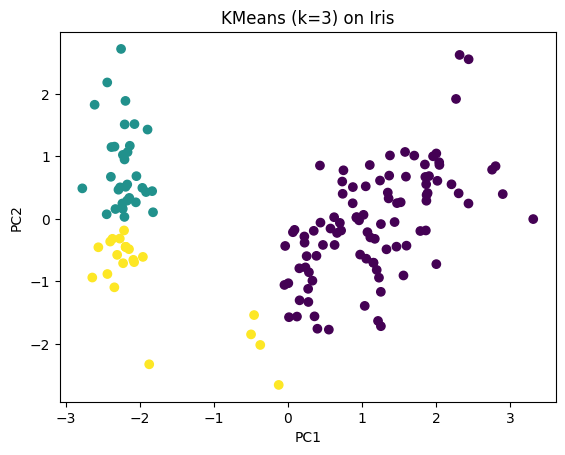

In [4]:
# Метод 1 — KMeans
from sklearn.cluster import KMeans

labels_kmeans = KMeans(n_clusters=3, n_init="auto", random_state=42).fit_predict(X_scaled)
plot_2d(X2, labels_kmeans, "KMeans (k=3) on Iris")

#### KMeans ищет центры кластеров и относит каждую точку к ближайшему центру. Алгоритм KMeans разделил объекты на три кластера. Кластеры имеют компактную форму и хорошо отделены друг от друга.

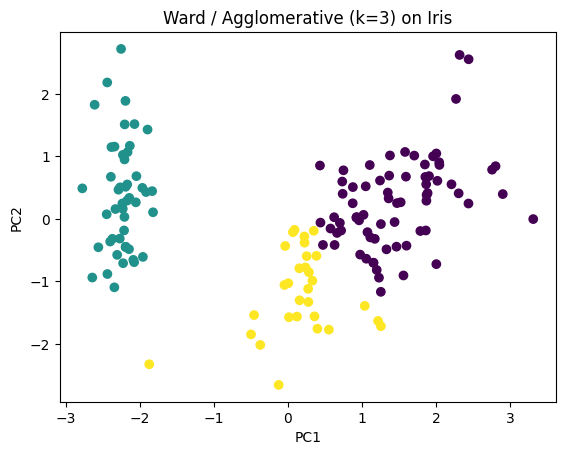

In [5]:
# Метод 2 — Ward (AgglomerativeClustering)
from sklearn.cluster import AgglomerativeClustering

labels_ward = AgglomerativeClustering(n_clusters=3, linkage="ward").fit_predict(X_scaled)
plot_2d(X2, labels_ward, 'Ward / Agglomerative (k=3) on Iris')

#### Иерархический метод Ward также разделил данные на три кластера. Полученные группы имеют структуру, похожую на результат метода KMeans.

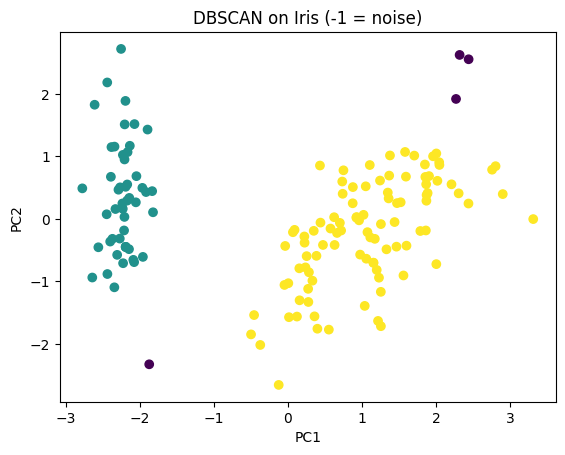

Unique labels: [-1  0  1]


In [6]:
# Метод 3 — DBSCAN
from sklearn.cluster import DBSCAN

labels_db = DBSCAN(eps=0.9, min_samples=5).fit_predict(X_scaled)
plot_2d(X2, labels_db, "DBSCAN on Iris (-1 = noise)")
print("Unique labels:", np.unique(labels_db))

#### DBSCAN ищет области высокой плотности, а не фиксированное число кластеров. Метод DBSCAN выделяет кластеры на основе плотности точек. В результате часть объектов может быть определена как шум. Для датасета Iris алгоритм не всегда находит три чётких кластера, так как данные имеют относительно равномерную плотность.

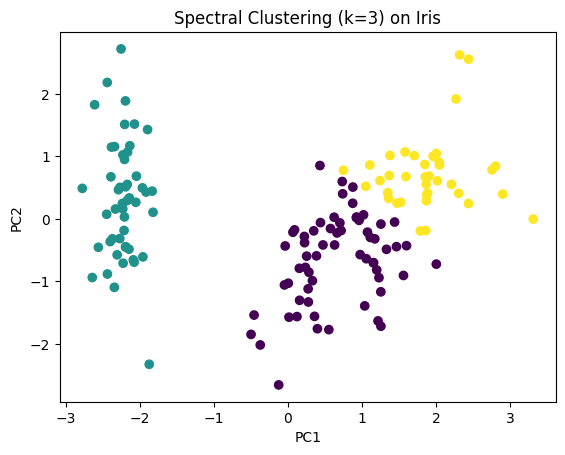

In [8]:
# Метод 4 — Spectral Clustering
from sklearn.cluster import SpectralClustering

labels_spec = SpectralClustering(
    n_clusters=3,
    affinity="rbf",
    gamma=1.0,
    assign_labels="kmeans",
    random_state=42
).fit_predict(X_scaled)

plot_2d(X2, labels_spec, "Spectral Clustering (k=3) on Iris")

#### Алгоритм сначала преобразует пространство данных, а потом выполняет кластеризацию. Спектральная кластеризация также выделяет три группы объектов. Метод позволяет находить более сложные структуры данных, так как использует спектральное преобразование графа похожести объектов.

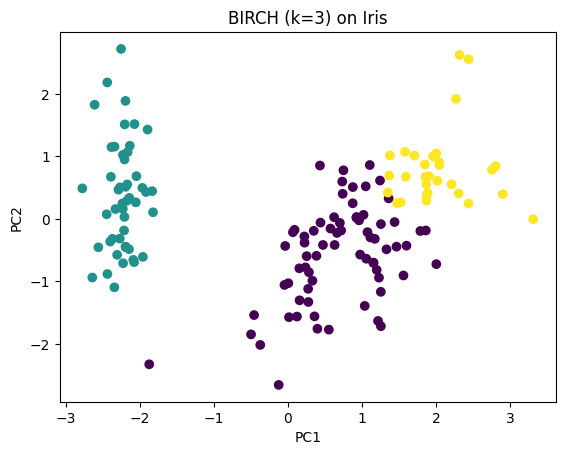

In [9]:
# Метод 5 — BIRCH
from sklearn.cluster import Birch

labels_birch = Birch(n_clusters=3, threshold=0.5).fit_predict(X_scaled)
plot_2d(X2, labels_birch, "BIRCH (k=3) on Iris")

#### Алгоритм строит иерархическое дерево кластеров. Метод BIRCH формирует кластеры на основе построения дерева кластерных признаков. Алгоритм эффективно работает с большими объёмами данных и позволяет получать компактные группы объектов.

#### Методы, основанные на расстояниях (KMeans и Ward), дают наиболее стабильные результаты. Метод DBSCAN показывает иную структуру кластеров, так как основан на плотности точек. Spectral Clustering и BIRCH также позволяют выявить группы объектов, демонстрируя эффективность кластеризации для анализа структуры данных.